## Tarea 4: ¿Cómo vamos a entrenar la RN? parte 2 — Soluciones (parte práctica)

Soluciones de los ejercicios de Python de la tarea de práctica. La numeración corresponde a la versión actual de `Tareas/Tarea4.ipynb`. Úsalas para verificar tu trabajo (o el de tu agente) **después** de intentarlo.

### Ejercicios de Python:

1. Usando Pytorch: implementa una red neuronal superficial con una sola capa intermedia y compara que pasa si usas una función de activación sigmoide vs una ReLU. Muestra lo siguiente: 
    
    a. curvas de pérdida del conjunto de entrenamiento y validación 

    b. normas de gradiente por época 

    c. histogramas de los pesos 

    d. cambia la tasa de aprendizaje para encontrar el rango estable 
    
Acá abajo puedes encontrar una función que genera datos artificiales para la red y una serie de hiperparámetros que tienes que usar



In [3]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

def make_nonlinear_synthetic(seed: int = 42,
                             n_samples: int = 2000,
                             input_dim: int = 1,
                             val_frac: float = 0.2,
                             batch_size: int = 64,
                             heteroscedastic: bool = True):
    """
    Genera datos sintéticos no-lineales para regresión:
      x ~ Uniform(-3, 3) (entrada de dimensión input_dim)
      y = sin(3*x_0) + 0.5 * x_0 + 0.3 * sin(2*x_1)  (si input_dim>1)
      ruido ~ N(0, sigma^2) con sigma creciente con |x_0| si heteroscedastic=True

    Devuelve: train_loader, val_loader, (X_train_np, y_train_np, X_val_np, y_val_np)
    - Los loaders devuelven tensores float32
    - Semilla controlada para reproducibilidad
    """
    rng = np.random.RandomState(seed)

    # Entradas: shape (n_samples, input_dim)
    X = rng.uniform(-3.0, 3.0, size=(n_samples, input_dim)).astype(np.float32)

    # Construcción de una función objetivo no lineal que depende al menos de x[:,0]
    x0 = X[:, 0]
    y = np.sin(3.0 * x0) + 0.5 * x0
    if input_dim > 1:
        # si hay más dimensiones, agregar una dependencia suave en x1
        x1 = X[:, 1]
        y += 0.3 * np.sin(2.0 * x1)

    # Ruido heterocedástico: sigma aumenta con |x0|
    if heteroscedastic:
        sigma = 0.08 + 0.25 * (np.abs(x0) / np.max(np.abs(x0)))
    else:
        sigma = np.full_like(x0, 0.2)

    noise = rng.normal(0.0, sigma).astype(np.float32)
    y = (y + noise).astype(np.float32).reshape(-1, 1)

    # split train / val
    n_val = int(n_samples * val_frac)
    idx = np.arange(n_samples)
    rng.shuffle(idx)
    tr_idx = idx[n_val:]
    va_idx = idx[:n_val]

    X_train = X[tr_idx]
    y_train = y[tr_idx]
    X_val = X[va_idx]
    y_val = y[va_idx]

    # DataLoaders (torch tensors)
    train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    val_ds   = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(y_val))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

    # También devolvemos numpy arrays para evaluaciones fuera de torch si se desea
    return train_loader, val_loader, (X_train, y_train, X_val, y_val)

SEED = 1234                 # semilla fija para que todos obtengan resultados similares
N_SAMPLES = 2000
INPUT_DIM = 1               # puedes poner 2 si quieres un problema 2D
BATCH_SIZE = 64
EPOCHS = 80                 # suficiente para ver convergencia en este toy problem
HIDDEN = 64                 # neuronas en la capa oculta
LR = 1e-2                   # tasa de aprendizaje inicial para comparar ReLU vs Sigmoid



def find_device():
    if torch.backends.mps.is_available():
        DEVICE = torch.device("mps")
    elif torch.cuda.is_available():
        DEVICE = torch.device("cuda")
    else:
        DEVICE = torch.device("cpu")
    return DEVICE

DEVICE = find_device()


Epoch 1/80 train 0.690239 val 0.560975 max_grad 10.2303
Epoch 17/80 train 0.437164 val 0.452179 max_grad 2.46592
Epoch 33/80 train 0.353027 val 0.364163 max_grad 1.90806
Epoch 49/80 train 0.285573 val 0.298884 max_grad 1.83004
Epoch 65/80 train 0.225526 val 0.229628 max_grad 1.27747
Epoch 80/80 train 0.184187 val 0.190273 max_grad 1.51581
Epoch 1/80 train 1.126329 val 0.714294 max_grad 4.08343
Epoch 17/80 train 0.553750 val 0.565657 max_grad 1.56383
Epoch 33/80 train 0.549898 val 0.559662 max_grad 1.478
Epoch 49/80 train 0.547053 val 0.568911 max_grad 2.12402
Epoch 65/80 train 0.542398 val 0.555544 max_grad 1.82458
Epoch 80/80 train 0.538653 val 0.561764 max_grad 1.71021


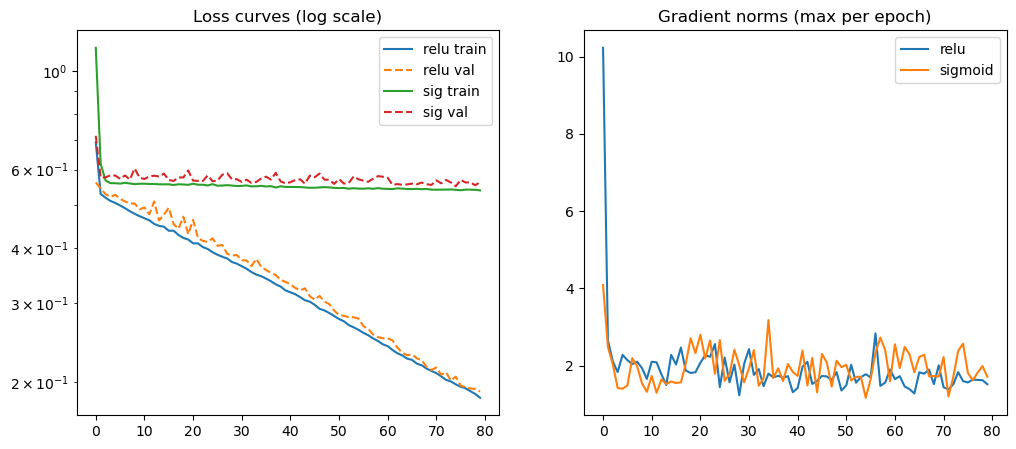

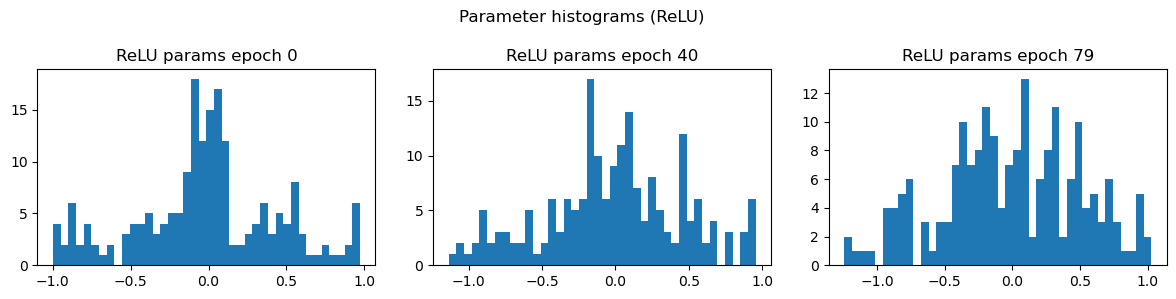

In [4]:
import torch
from torch import nn
import math
import matplotlib.pyplot as plt

# Modelo: una capa oculta
class SimpleMLP(nn.Module):
    def __init__(self, in_dim=1, hidden=64, activation='relu'):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.act = nn.ReLU() if activation == 'relu' else nn.Sigmoid()
        self.fc2 = nn.Linear(hidden, 1)

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

# función de entrenamiento que guarda métricas necesarias
def train_with_metrics(model, train_loader, val_loader, lr=1e-2, epochs=80, device='cpu'):
    model = model.to(device)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = {'train_loss':[], 'val_loss':[], 'grad_norms':[], 'param_snapshots':[]}
    for epoch in range(epochs):
        # train
        model.train()
        total_loss = 0.0; n = 0; max_grad = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = model(Xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad()
            loss.backward()
            # grad-norm
            total_sq = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    total_sq += float(p.grad.detach().norm(2).item())**2
            grad_norm = math.sqrt(total_sq)
            max_grad = max(max_grad, grad_norm)
            opt.step()
            total_loss += float(loss.item()) * Xb.shape[0]
            n += Xb.shape[0]
        train_loss = total_loss / n

        # val
        model.eval()
        vtotal=0; vn=0
        with torch.no_grad():
            for Xv, yv in val_loader:
                Xv, yv = Xv.to(device), yv.to(device)
                pv = model(Xv)
                vloss = loss_fn(pv, yv)
                vtotal += float(vloss.item()) * Xv.shape[0]
                vn += Xv.shape[0]
        val_loss = vtotal / vn

        # snapshots
        params = torch.cat([p.data.view(-1).cpu() for p in model.parameters()]).numpy().copy()
        history['param_snapshots'].append(params)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['grad_norms'].append(max_grad)

        if (epoch % (epochs//5) == 0) or (epoch == epochs-1):
            print(f"Epoch {epoch+1}/{epochs} train {train_loss:.6f} val {val_loss:.6f} max_grad {max_grad:.6g}")
    return history, model

# GENERAR DATOS (reproducible)
train_loader, val_loader, (X_tr, y_tr, X_val, y_val) = make_nonlinear_synthetic(seed=SEED,
                                                                                n_samples=N_SAMPLES,
                                                                                input_dim=INPUT_DIM,
                                                                                val_frac=0.2,
                                                                                batch_size=BATCH_SIZE,
                                                                                heteroscedastic=True)

# Instanciar y entrenar dos modelos (mismo seed para inicialización)
torch.manual_seed(SEED); model_relu = SimpleMLP(in_dim=INPUT_DIM, hidden=HIDDEN, activation='relu')
torch.manual_seed(SEED); model_sig  = SimpleMLP(in_dim=INPUT_DIM, hidden=HIDDEN, activation='sigmoid')

hist_relu, mdl_relu = train_with_metrics(model_relu, train_loader, val_loader, lr=LR, epochs=EPOCHS, device=DEVICE)
hist_sig,  mdl_sig  = train_with_metrics(model_sig,  train_loader, val_loader, lr=LR, epochs=EPOCHS, device=DEVICE)

# PLOTS: pérdidas y grad-norms (ejemplo)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(hist_relu['train_loss'], label='relu train'); plt.plot(hist_relu['val_loss'], '--', label='relu val')
plt.plot(hist_sig['train_loss'], label='sig train'); plt.plot(hist_sig['val_loss'], '--', label='sig val')
plt.yscale('log'); plt.legend(); plt.title('Loss curves (log scale)')

plt.subplot(1,2,2)
plt.plot(hist_relu['grad_norms'], label='relu'); plt.plot(hist_sig['grad_norms'], label='sigmoid')
plt.legend(); plt.title('Gradient norms (max per epoch)')
plt.show()

# Histograms de pesos (epoch 0, mid, final) para ReLU (ejemplo)
snap_r = hist_relu['param_snapshots']
idxs = [0, len(snap_r)//2, len(snap_r)-1]
plt.figure(figsize=(12,3))
for i, idx in enumerate(idxs):
    plt.subplot(1,3,i+1)
    plt.hist(snap_r[idx], bins=40)
    plt.title(f'ReLU params epoch {idx}')
plt.suptitle('Parameter histograms (ReLU)')
plt.tight_layout()
plt.show()


**Respuesta:**

1. Curvas de pérdida (train / val)
- ReLU: suele converger más rápido y de manera más estable en problemas no-lineales con activaciones que no saturan. La curva mostrará una caída más pronunciada en las primeras épocas y raramente estancamiento prematuro por saturación.
- Sigmoid: puede ser más lento y más ruidoso. Si muchas unidades caen en la región saturada (inputs grandes positivos o negativos), la pendiente local es muy pequeña y las actualizaciones son pequeñas → la curva de pérdida desciende lentamente o se estanca.

2. Normas de gradiente por época
- ReLU: grad-norm típicamente mayor (no se atenúa por saturación), con picos al inicio y luego estabilización. ReLU da gradientes no nulos en la región activa (derivada 1).
- Sigmoid: grad-norm más pequeño, especialmente si las pre-activaciones caen en zonas saturadas; observarás normas cercanas a 0 en capas tempranas si hay vanishing gradients.

3. Histogramas de pesos
- ReLU: pesos pueden desarrollar colas y desplazarse (asimetría), la distribución puede volverse más ancha si lr es grande. Inicialmente la distribución refleja la inicialización; con entrenamiento se desplaza.
- Sigmoid: pesos tienden a ser más pequeños debido a actualizaciones más pequeñas; histograma más estrecho si la saturación limita la magnitud de los cambios.

4. LR sweep — rango estable: Espera encontrar un rango estable aproximado: para este toy-problem LR ~ 1e-3–1e-2 es estable tanto para ReLU como para Sigmoid; ReLU puede tolerar LRs algo mayores; Sigmoid típicamente requiere LR más pequeño para evitar oscilaciones o saturación (si lr es grande, los inputs pueden saltar a saturación y gradientes desaparecer).

2. Implementa una red neuronal superficial con una capa oculta y realiza los experimentos que se piden acá abajo. Además, implementa y compara la versión con BatchNorm en la capa oculta.
    
    a. Implementa una red con lo siguiente `in_dim, hidden, activation, use_batchnorm=False` que si `use_batchnorm=True` inserta `nn.BatchNorm1d(hidden)` justo después de la capa lineal y antes de la activación.
    
    b. Entrena 4 configuraciones distintas: {ReLU, Sigmoid} × {BatchNorm off, BatchNorm on}, usando la misma semilla y split. Guarda train/val loss, grad-norm, param snapshots.

Para cada configuración reporta: 
- curvas train/val
- grad-norm per epoch
- histograms de parámetros (epoch 0, mitad, final)
- resumen final: val-loss y RMSE (si problema de regresión)

    c. Haz un LR-sweep (intenta varias tasas de aprendizaje) por cada configuración y determina la zona estable de lr. Grafica val-loss final vs lr.

    d. Interpretación: compara el efecto de BatchNorm en la dinámica de entrenamiento para cada activación y conecta tus observaciones con los argumentos que vimos en clase sobre propagación de la señal. 

Acá abajo vas a encontrar una función que genera datos y los hiperparámetros para esta pregunta

In [6]:
## para el ejercicio 2
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

def make_nonlinear_synthetic_v2(seed: int = 2025,
                                n_samples: int = 2500,
                                input_dim: int = 1,
                                val_frac: float = 0.2,
                                batch_size: int = 64,
                                heteroscedastic: bool = True):
    """
    Generador reproducible para el ejercicio 2.
    - no linealidad: mezcla de sinusoides y término cuadrático para forzar no-linealidad.
    - heteroscedastic: ruido con varianza que aumenta con |x|.
    Devuelve: train_loader, val_loader, (X_train, y_train, X_val, y_val) (numpy arrays para checks)
    """
    rng = np.random.RandomState(seed)

    X = rng.uniform(-3.0, 3.0, size=(n_samples, input_dim)).astype(np.float32)
    x0 = X[:, 0]

    # función objetivo no-lineal (mezcla de sin y cuadrático)
    y = 0.8 * np.sin(2.5 * x0) + 0.4 * x0 - 0.2 * (x0**2)

    if input_dim > 1:
        # si hay más dimensiones añadimos interacción ligera
        x1 = X[:, 1]
        y += 0.3 * np.sin(1.5 * x1) + 0.1 * x0 * x1

    # ruido heterocedástico: sigma crece con |x0|
    if heteroscedastic:
        sigma = 0.05 + 0.25 * (np.abs(x0) / np.max(np.abs(x0)))
    else:
        sigma = np.full_like(x0, 0.15)

    noise = rng.normal(0.0, sigma).astype(np.float32)
    y = (y + noise).astype(np.float32).reshape(-1, 1)

    # split
    n_val = int(n_samples * val_frac)
    idx = np.arange(n_samples)
    rng.shuffle(idx)
    tr_idx = idx[n_val:]
    va_idx = idx[:n_val]

    X_train = X[tr_idx]; y_train = y[tr_idx]
    X_val   = X[va_idx]; y_val   = y[va_idx]

    # DataLoaders
    train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    val_ds   = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(y_val))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, (X_train, y_train, X_val, y_val)

# Parámetros reproducibles para los estudiantes
SEED = 2025
N_SAMPLES = 2500
INPUT_DIM = 1
BATCH_SIZE = 64
EPOCHS = 80
HIDDEN = 64
LR_DEFAULT = 1e-2




=== Config: relu | BatchNorm: False ===

 Epoch 1/80 | train 0.401291 | val 0.358812 | max_grad 10.4222
 Epoch 17/80 | train 0.261088 | val 0.275772 | max_grad 2.81063
 Epoch 33/80 | train 0.193541 | val 0.206943 | max_grad 2.08187
 Epoch 49/80 | train 0.143144 | val 0.143336 | max_grad 2.05758
 Epoch 65/80 | train 0.106835 | val 0.120255 | max_grad 2.34333
 Epoch 80/80 | train 0.083551 | val 0.087188 | max_grad 1.48657

=== Config: relu | BatchNorm: True ===

 Epoch 1/80 | train 0.535296 | val 0.399232 | max_grad 9.69891
 Epoch 17/80 | train 0.352476 | val 0.371591 | max_grad 3.99873
 Epoch 33/80 | train 0.382070 | val 0.393186 | max_grad 5.67695
 Epoch 49/80 | train 0.359907 | val 0.333569 | max_grad 4.91362
 Epoch 65/80 | train 0.353545 | val 0.324339 | max_grad 3.28469
 Epoch 80/80 | train 0.375760 | val 0.333286 | max_grad 3.31353

=== Config: sigmoid | BatchNorm: False ===

 Epoch 1/80 | train 0.778904 | val 0.714645 | max_grad 8.18398
 Epoch 17/80 | train 0.494468 | val 0.53779

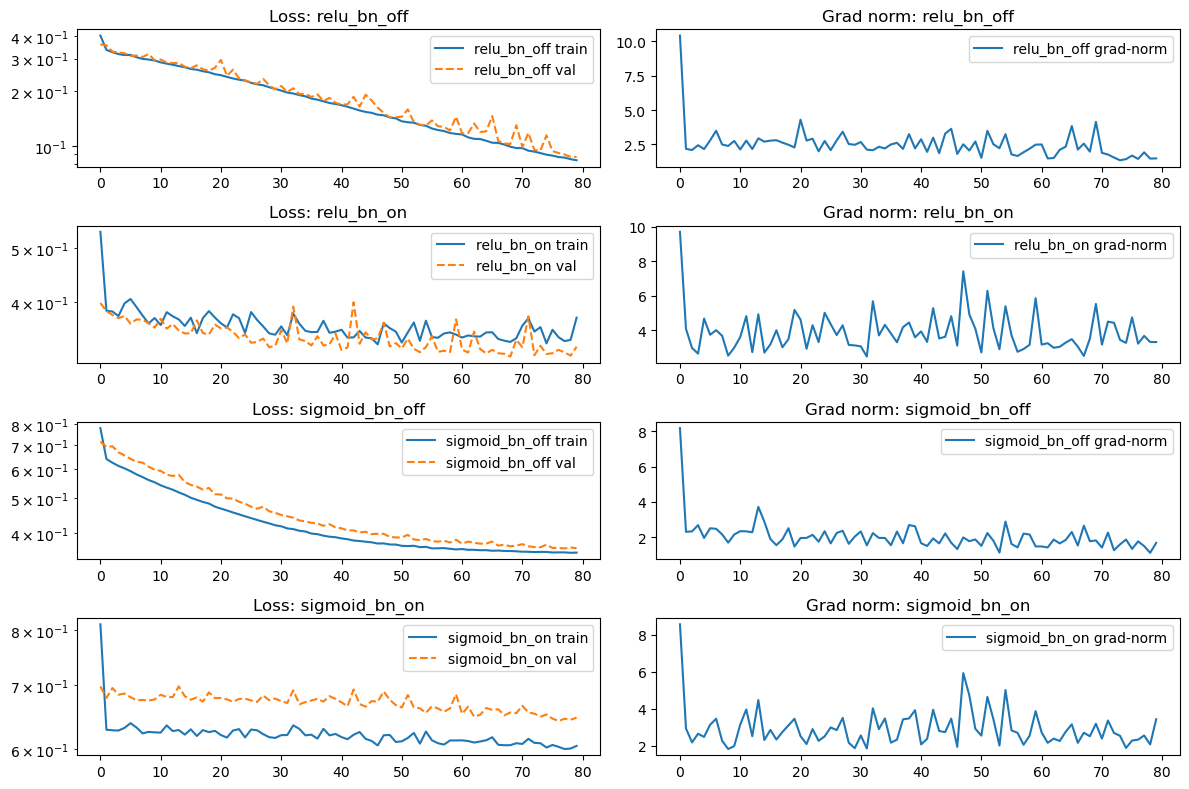

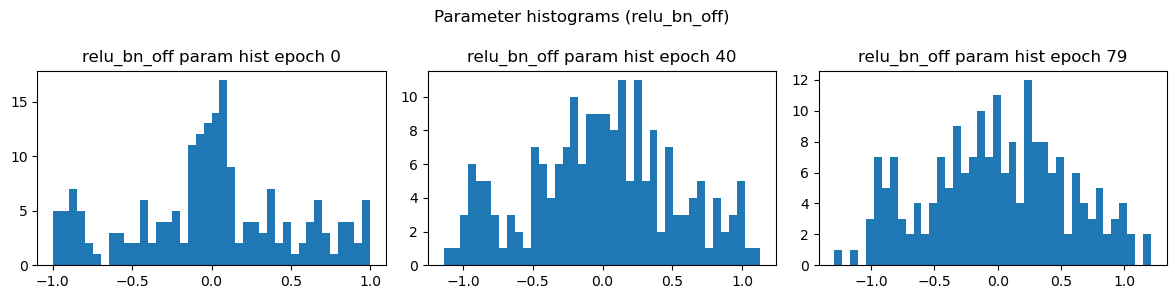

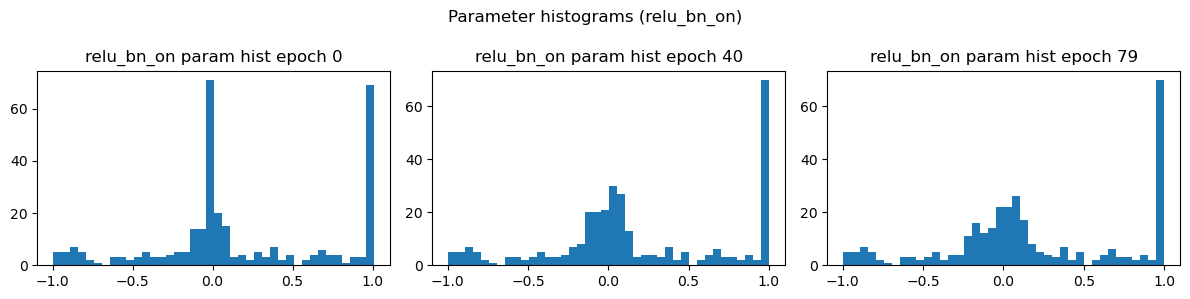

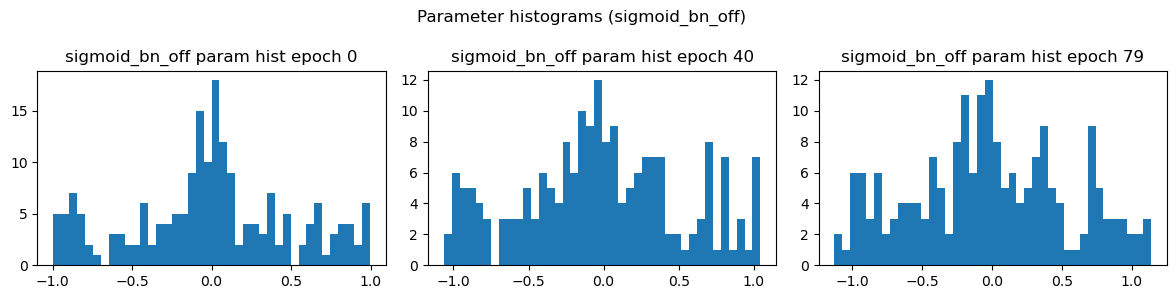

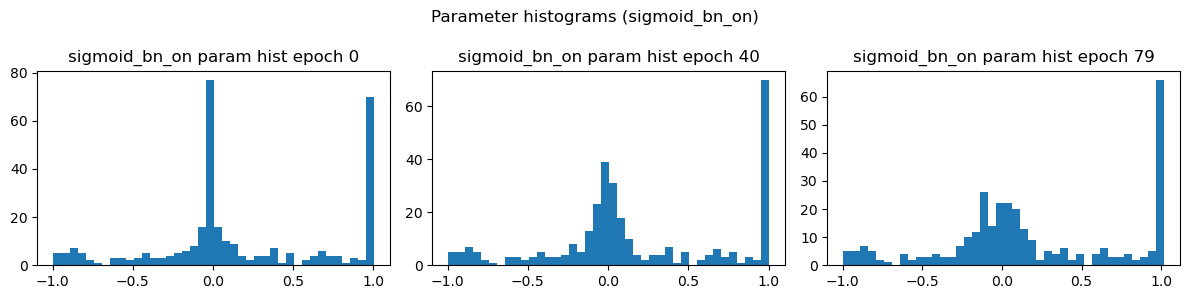

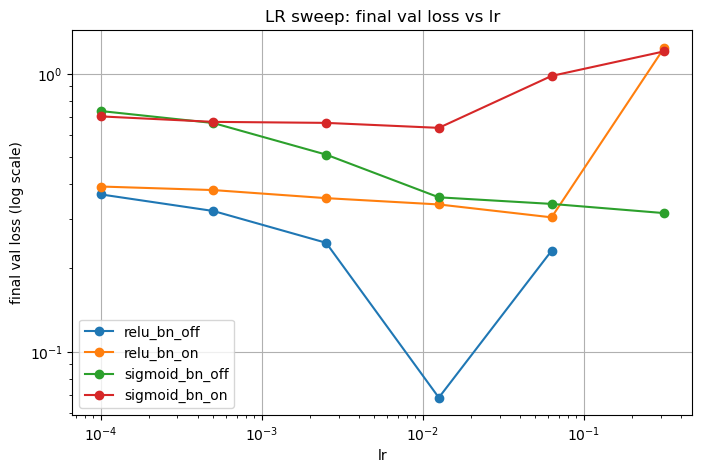


=== Resumen final por configuración ===
relu_bn_off                    | val-loss: 0.087188 | RMSE ($-scale synthetic): 0.2953
relu_bn_on                     | val-loss: 0.333286 | RMSE ($-scale synthetic): 0.5773
sigmoid_bn_off                 | val-loss: 0.364036 | RMSE ($-scale synthetic): 0.6034
sigmoid_bn_on                  | val-loss: 0.647625 | RMSE ($-scale synthetic): 0.8048


In [7]:
import math
import copy
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

# ---------------- Modelo con BatchNorm opcional ----------------
class ShallowMLP(nn.Module):
    def __init__(self, in_dim=1, hidden=64, activation='relu', use_batchnorm=False):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.use_bn = use_batchnorm
        if use_batchnorm:
            self.bn1 = nn.BatchNorm1d(hidden)
        if activation == 'relu':
            self.act = nn.ReLU()
        elif activation == 'sigmoid':
            self.act = nn.Sigmoid()
        else:
            raise ValueError("activation must be 'relu' or 'sigmoid'")
        self.fc2 = nn.Linear(hidden, 1)

    def forward(self, x):
        z = self.fc1(x)
        if self.use_bn:
            z = self.bn1(z)
        z = self.act(z)
        return self.fc2(z)

# ---------------- Entrenador que guarda métricas ----------------
def train_record(model, train_loader, val_loader, lr=1e-2, epochs=80, device='cpu'):
    model = model.to(device)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = {'train_loss':[], 'val_loss':[], 'grad_norms':[], 'param_snapshots':[]}
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0; n = 0; max_grad = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = model(Xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad()
            loss.backward()
            # grad-norm L2 aggregated
            total_sq = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    total_sq += float(p.grad.detach().norm(2).item())**2
            grad_norm = math.sqrt(total_sq)
            max_grad = max(max_grad, grad_norm)
            opt.step()
            total_loss += float(loss.item()) * Xb.shape[0]
            n += Xb.shape[0]
        train_loss = total_loss / n

        # validación
        model.eval()
        vtotal = 0.0; vn = 0
        with torch.no_grad():
            for Xv, yv in val_loader:
                Xv, yv = Xv.to(device), yv.to(device)
                pv = model(Xv)
                vloss = loss_fn(pv, yv)
                vtotal += float(vloss.item()) * Xv.shape[0]
                vn += Xv.shape[0]
        val_loss = vtotal / vn

        # snapshot de parámetros (vector plano, en cpu)
        params = torch.cat([p.data.view(-1).cpu() for p in model.parameters()]).numpy().copy()
        history['param_snapshots'].append(params)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['grad_norms'].append(max_grad)

        # opcional: feedback
        if (epoch % (epochs//5) == 0) or (epoch == epochs-1):
            print(f" Epoch {epoch+1}/{epochs} | train {train_loss:.6f} | val {val_loss:.6f} | max_grad {max_grad:.6g}")
    return history, model

# ---------------- Ejecutar los 4 experimentos ----------------
train_loader, val_loader, (Xtr_np, ytr_np, Xval_np, yval_np) = make_nonlinear_synthetic_v2(seed=SEED,
                                                                                           n_samples=N_SAMPLES,
                                                                                           input_dim=INPUT_DIM,
                                                                                           val_frac=0.2,
                                                                                           batch_size=BATCH_SIZE,
                                                                                           heteroscedastic=True)

configs = [
    ('relu', False),
    ('relu', True),
    ('sigmoid', False),
    ('sigmoid', True),
]

results_all = {}
for act, use_bn in configs:
    print("\n=== Config:", act, "| BatchNorm:", use_bn, "===\n")
    # fijar seed para inicialización comparable
    torch.manual_seed(SEED)
    model = ShallowMLP(in_dim=INPUT_DIM, hidden=HIDDEN, activation=act, use_batchnorm=use_bn)
    history, trained = train_record(model, train_loader, val_loader, lr=LR_DEFAULT, epochs=EPOCHS, device=DEVICE)
    key = f"{act}_bn_{'on' if use_bn else 'off'}"
    results_all[key] = {'history': history, 'model': trained}

# ---------------- LR sweep por configuración ----------------
# Valores de lr a barrer (logspace)
lrs = np.logspace(-4, -0.5, num=6)  # [1e-4 ... ~0.316]
lr_sweep_results = {}

for act, use_bn in configs:
    key = f"{act}_bn_{'on' if use_bn else 'off'}"
    lr_vals = []
    final_vals = []
    print("\n--- LR sweep for", key)
    for lr in lrs:
        torch.manual_seed(SEED)
        model = ShallowMLP(in_dim=INPUT_DIM, hidden=HIDDEN, activation=act, use_batchnorm=use_bn)
        hist, _ = train_record(model, train_loader, val_loader, lr=lr, epochs=EPOCHS, device=DEVICE)
        lr_vals.append(lr)
        final_vals.append(hist['val_loss'][-1])
    lr_sweep_results[key] = {'lrs': np.array(lr_vals), 'final_val': np.array(final_vals)}

# ---------------- Funciones de plotting resumidas ----------------
def plot_loss_and_grad(results_all):
    plt.figure(figsize=(12,8))
    i=1
    for k,v in results_all.items():
        hist = v['history']
        plt.subplot(4,2,i)
        plt.plot(hist['train_loss'], label=f'{k} train')
        plt.plot(hist['val_loss'], '--', label=f'{k} val')
        plt.yscale('log'); plt.title(f'Loss: {k}'); plt.legend()
        i+=1
        plt.subplot(4,2,i)
        plt.plot(hist['grad_norms'], label=f'{k} grad-norm')
        plt.title(f'Grad norm: {k}'); plt.legend()
        i+=1
    plt.tight_layout(); plt.show()

def plot_param_histograms_for_key(results_all, key):
    hist = results_all[key]['history']
    snaps = hist['param_snapshots']
    idxs = [0, len(snaps)//2, len(snaps)-1]
    plt.figure(figsize=(12,3))
    for i, idx in enumerate(idxs):
        plt.subplot(1,3,i+1)
        plt.hist(snaps[idx], bins=40)
        plt.title(f'{key} param hist epoch {idx}')
    plt.suptitle(f'Parameter histograms ({key})'); plt.tight_layout(); plt.show()

def plot_lr_sweep(lr_sweep_results):
    plt.figure(figsize=(8,5))
    for k, v in lr_sweep_results.items():
        plt.plot(v['lrs'], v['final_val'], marker='o', label=k)
    plt.xscale('log'); plt.yscale('log')
    plt.xlabel('lr'); plt.ylabel('final val loss (log scale)')
    plt.title('LR sweep: final val loss vs lr'); plt.legend(); plt.grid(True); plt.show()

# ---------------- Dibujar resultados ----------------
plot_loss_and_grad(results_all)

# Histograms para cada configuración (ejemplo)
for key in results_all.keys():
    plot_param_histograms_for_key(results_all, key)

# LR sweep plot
plot_lr_sweep(lr_sweep_results)

# ---------------- Resumen numérico final (val-loss y RMSE) ----------------
from math import sqrt
print("\n=== Resumen final por configuración ===")
for k,v in results_all.items():
    hist = v['history']
    val_loss_final = hist['val_loss'][-1]
    # calcular RMSE en val (usar el modelo entrenado)
    model = v['model'].to(DEVICE); model.eval()
    with torch.no_grad():
        Xv_t = torch.from_numpy(Xval_np.astype(np.float32)).to(DEVICE)
        preds = model(Xv_t).cpu().numpy().ravel()
    rmse = sqrt(((preds.reshape(-1,1) - yval_np)**2).mean())
    print(f"{k:30s} | val-loss: {val_loss_final:.6f} | RMSE ($-scale synthetic): {rmse:.4f}")


## Interpretación 

1. Curvas train/val
- ReLU sin BatchNorm: típicamente muestra convergencia rápida y estable; curvas de train y val bajan y se estabilizan sin estancamiento precoz.
- ReLU con BatchNorm: converge aún más rápido o de manera más suave; BatchNorm reduce la variabilidad entre minibatches y permite usar un lr algo mayor.
- Sigmoid sin BatchNorm: puede mostrar descenso más lento; si muchas unidades se saturan verás estancamiento (plateau).
0 Sigmoid con BatchNorm: BatchNorm rescata la sigmoide en buena medida: normaliza la distribución antes de la activación, evitando que las pre-activaciones caigan en la región saturada; por eso la curva se vuelve más parecida a ReLU+BN.

BatchNorm mejora notablemente el comportamiento de la sigmoide y ayuda algo a ReLU; para activaciones que saturan, BN reduce el problema.

2. Normas de gradiente por época
- Sin BN + Sigmoid: grad-norm pequeños y decrecientes → signo de vanishing gradients en capas anteriores.
- Con BN + Sigmoid: grad-normes más altos y más estables; BN mantiene la señal en magnitud "útil".
- ReLU: grad-norm más robusto; con BN los picos son más controlados.


3. Histogramas de pesos (epoch 0, mitad, final)
- Sin BN: puede aparecer dispersión menor en Sigmoid (menor magnitud de parámetros, por aprendizaje lento).
- Con BN: parámetros pueden alcanzar magnitudes mayores y estables (porque las activaciones están normalizadas, permitiendo a la red escalar pesos sin saturar la activación).


4. LR sweep (zona estable)
- Sin BN y Sigmoid: rango estable suele ser más pequeño (ej. ~1e-4 → 1e-3).
- Con BN: margen estable se amplía (BN suele permitir lr 2–10× mayor sin divergencia).
- ReLU tolera lr más grandes que Sigmoid; ReLU+BN tolera aún más.


5. Pistas para la interpretación teórica

Por qué BatchNorm ayuda: BN normaliza pre-activaciones por minibatch, manteniendo su media cercana a 0 y varianza cerca de 1; esto preserva la señal y evita que activaciones saturantes (sigmoid) caigan en regiones donde la derivada ≈ 0. En el lenguaje de Prince: BN mejora el conditioning de la cadena de Jacobianos y reduce el efecto multiplicativo de singular values problemáticos.

- Relación con inicialización: si inicializas mal, incluso ReLU puede explotar/atrofiarse; Xavier/He ayudan, y BN reduce sensibilidad a la inicialización.

- Gradient flow: BN y ReLU facilitan un flujo de gradiente no atenuado; Sigmoid sin BN tiende a atenuar gradientes (vanishing), haciendo el aprendizaje más lento.